In [1]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt

#### NHANES

In [2]:
#import dataframe output from table 1
df = pd.read_csv(r"Z:\Output\Data tables\EyeFields3.csv")
df = df[['SEQN', 'RRVCDR']]

In [3]:
print('N of Respondents: ', df['SEQN'].nunique())
df.shape

N of Respondents:  5828


(5828, 2)

In [4]:
df.isna().sum()

SEQN         0
RRVCDR    5108
dtype: int64

In [5]:
#drop all records without the re-read
df= df.dropna()

In [6]:
df['RRVCDR'].value_counts()

2.0    418
1.0    302
Name: RRVCDR, dtype: int64

#### Model B
*Model A has no values


In [7]:
#import B_output
b = pd.read_csv(r"Z:\Data\output-B_upd.csv")
b = b[['SEQN','Laterality', 'VCDR']]

In [8]:
print('N in model: ', b['SEQN'].nunique())

N in model:  5827


In [9]:
b = b.pivot(index = 'SEQN', columns = 'Laterality', values = 'VCDR')

In [10]:
b['Worse'] = b[['OD', 'OS']].max(axis=1)

In [11]:
def categorise(b):
    if b['Worse'] < 0.6 :
        return 1
    elif b['Worse'] >= 0.6:
        return 2

In [12]:
b['Worse'] = b.apply(lambda b: categorise(b), axis = 1)

In [13]:
b['Worse'].value_counts()

1.0    5511
2.0     246
Name: Worse, dtype: int64

#### Merge nhanes and A model


In [14]:
c = pd.merge(df, b, on='SEQN')
print('N in NHANES and Model: ', c['SEQN'].nunique())

N in NHANES and Model:  720


In [15]:
c = c[['SEQN','RRVCDR', 'Worse']]

In [16]:
c.isna().sum()

SEQN      0
RRVCDR    0
Worse     3
dtype: int64

In [17]:
c= c.dropna(subset=['Worse'], how = 'all')

In [18]:
actual = c['RRVCDR']
predicted = c['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

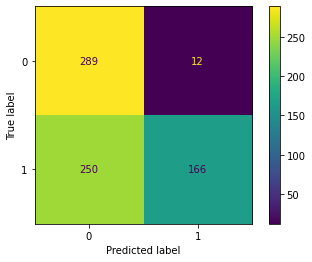

In [19]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [20]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         1.0       0.54      0.96      0.69       301
         2.0       0.93      0.40      0.56       416

    accuracy                           0.63       717
   macro avg       0.73      0.68      0.62       717
weighted avg       0.77      0.63      0.61       717



#### Model F

In [21]:
#import F_output
f = pd.read_csv(r"Z:\Data\output-F_upd.csv")
f = f[['SEQN','Laterality', 'VCDR']]

In [22]:
print('N in model F: ', f['SEQN'].nunique())

N in model F:  5827


In [23]:
f = f.pivot(index = 'SEQN', columns = 'Laterality', values = 'VCDR')
f['Worse'] = f[['OD', 'OS']].max(axis=1)

In [24]:
def categorise(f):
    if f['Worse'] < 0.6 :
        return 1
    elif f['Worse'] >= 0.6:
        return 2

In [25]:
f['Worse'] = f.apply(lambda f: categorise(f), axis = 1)

f['Worse'].value_counts()


1.0    5059
2.0     457
Name: Worse, dtype: int64

In [26]:
g = pd.merge(df, f, on='SEQN')
print('N in NHANES and Model: ', g['SEQN'].nunique())

N in NHANES and Model:  720


In [27]:
g = g[['SEQN','RRVCDR', 'Worse']]

In [28]:
g.isna().sum()

SEQN       0
RRVCDR     0
Worse     13
dtype: int64

In [29]:
g= g.dropna()
g['SEQN'].nunique()

707

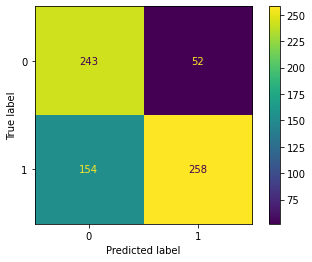

In [30]:
actual = g['RRVCDR']
predicted = g['Worse']

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [31]:
from sklearn.metrics import classification_report
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         1.0       0.61      0.82      0.70       295
         2.0       0.83      0.63      0.71       412

    accuracy                           0.71       707
   macro avg       0.72      0.72      0.71       707
weighted avg       0.74      0.71      0.71       707

